In [149]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [150]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [151]:
ticker = 'SPY'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2025-01-07", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

12570391it [06:59, 29942.84it/s]


In [152]:
ticker_hist

,Open,Close,high,low,volume,Datetime,transactions
0,364.01,364.00,364.03,363.97,373490.0,2022-10-17 09:30:00,469
1,364.00,364.02,364.11,363.99,38700.0,2022-10-17 09:30:01,559
2,364.02,364.14,364.16,364.02,53912.0,2022-10-17 09:30:02,577
3,364.14,364.37,364.37,364.14,65433.0,2022-10-17 09:30:03,831
4,364.36,364.47,364.49,364.32,117555.0,2022-10-17 09:30:04,1228
...,...,...,...,...,...,...,...
11284309,588.71,588.71,588.74,588.65,32297.0,2025-01-07 15:59:56,220
11284310,588.68,588.69,588.73,588.66,21383.0,2025-01-07 15:59:57,148
11284311,588.70,588.62,588.71,588.62,11794.0,2025-01-07 15:59:58,85
11284312,588.70,588.72,588.73,588.64,63677.0,2025-01-07 15:59:59,234


In [153]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}
ab_params['autocorr_slope'] = {}
ab_params['autocorr_intercept'] = {}

print('analyzing')

dates = ticker_hist['Date'].unique()

autocorrs = []
for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    #ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    #ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    #ticker_hist_date = ticker_hist_date.ffill()

    ticker_hist_date['logReturns'] = ticker_hist_date['logClose']-ticker_hist_date['logOpen']
    ticker_hist_date['logReturns_shifted'] = ticker_hist_date['logReturns'].shift(-1)

    autocorr_calc = ticker_hist_date[['logReturns', 'logReturns_shifted']].dropna()

    lr = LinearRegression()

    lr.fit(
        autocorr_calc['logReturns'].values.reshape(-1, 1),
        autocorr_calc['logReturns_shifted'].values
    )

    idiosyncratic_returns = lr.predict(autocorr_calc['logReturns'].values.reshape(-1, 1))

    noise_returns = autocorr_calc['logReturns_shifted'] - idiosyncratic_returns

    a = np.mean(noise_returns)
    b = np.sum(
            np.abs(noise_returns - a)
    ) / (len(noise_returns))

    ab_params['autocorr_slope'][date] = lr.coef_[0]
    ab_params['autocorr_intercept'][date] = lr.intercept_
    
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_32828/1358065433.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ticker_hist_date['logReturns'] = ticker_hist_date['logClose']-ticker_hist_date['logOpen']
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_32828/1358065433.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ticker_hist_date['logReturns_shifted'] = ticker_hist_date['logReturns'].shift(-1)
1it [00:00,  2.69it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm00

In [154]:
ticker_hist_date

,Open,Close,high,low,volume,Datetime,transactions,Date,Time,logClose,logOpen,logReturns,logReturns_shifted
11265389,597.420,597.6800,597.6800,597.3900,193271.0,2025-01-07 09:30:00,253,2025-01-07,09:30:00,6.393055,6.392620,0.000435,-0.000234
11265390,597.690,597.5500,597.6900,597.4399,10842.0,2025-01-07 09:30:01,334,2025-01-07,09:30:01,6.392838,6.393072,-0.000234,-0.000067
11265391,597.530,597.4900,597.5600,597.3900,12845.0,2025-01-07 09:30:02,1311,2025-01-07,09:30:02,6.392738,6.392804,-0.000067,-0.000084
11265392,597.460,597.4100,597.5101,597.4100,4925.0,2025-01-07 09:30:03,275,2025-01-07,09:30:03,6.392604,6.392687,-0.000084,-0.000058
11265393,597.395,597.3601,597.4000,597.3600,14548.0,2025-01-07 09:30:04,250,2025-01-07,09:30:04,6.392520,6.392579,-0.000058,-0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284309,588.710,588.7100,588.7400,588.6500,32297.0,2025-01-07 15:59:56,220,2025-01-07,15:59:56,6.377934,6.377934,0.000000,0.000017
11284310,588.680,588.6900,588.7300,588.6600,21383.0,2025-01-07 15:59:57,148,2025-01-07,15:59:57,6.377900,6.377883,0.000017,-0.000136
11284311,588.700,588.6200,588.7100,588.6200,11794.0,2025-01-07 15:59:58,85,2025-01-07,15:59:58,6.377781,6.377917,-0.000136,0.000034
11284312,588.700,588.7200,588.7300,588.6400,63677.0,2025-01-07 15:59:59,234,2025-01-07,15:59:59,6.377951,6.377917,0.000034,-0.000017


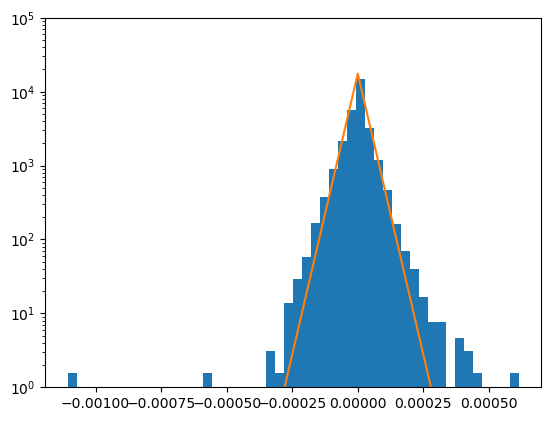

In [155]:
plt.hist(noise_returns, bins = 50, density = True)

plt.plot(
    np.arange(-0.0004, 0.0004, 0.00001),
    1 / (2*b) * np.exp(
        - np.abs(
            np.arange(-0.0004, 0.0004, 0.00001) - a
        )/(b)
    )
)
plt.ylim(10**0, 10**5)
plt.yscale('log')
plt.show()

In [131]:
ab_params_df = pd.DataFrame(ab_params)

In [132]:
ab_params_df

,a,b,autocorr_slope,autocorr_intercept
2022-10-17,7.253460e-08,0.000041,0.041615,-7.253460e-08
2022-10-18,7.901335e-09,0.000052,0.029918,-7.901335e-09
2022-10-19,1.074835e-06,0.000046,0.028070,-1.074835e-06
2022-10-20,3.385854e-07,0.000046,0.015212,-3.385854e-07
2022-10-21,2.356940e-07,0.000058,0.017953,-2.356940e-07
...,...,...,...,...
2024-12-27,-7.998723e-08,0.000026,0.028314,7.998723e-08
2024-12-30,-1.051206e-06,0.000028,0.018385,1.051206e-06
2024-12-31,3.312610e-07,0.000028,0.048849,-3.312610e-07
2025-01-02,-3.609684e-07,0.000040,0.024813,3.609684e-07


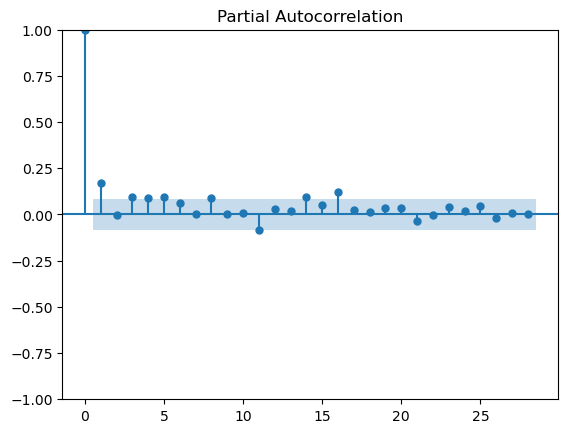

In [133]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

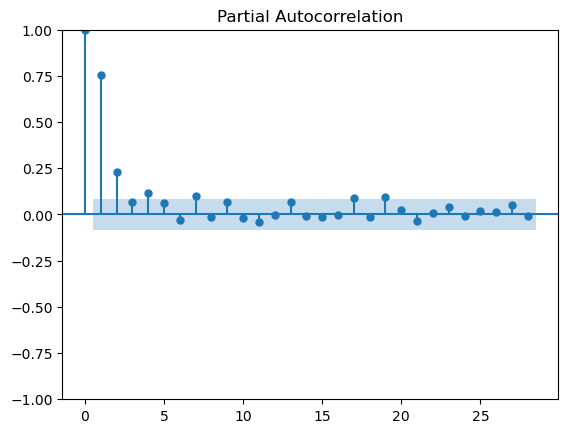

In [134]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

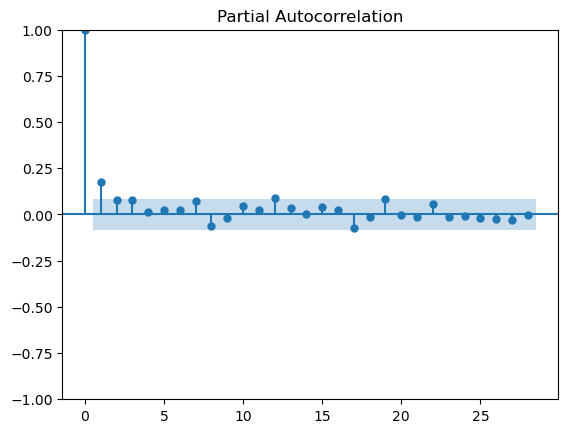

In [135]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_slope']
)
plt.show()

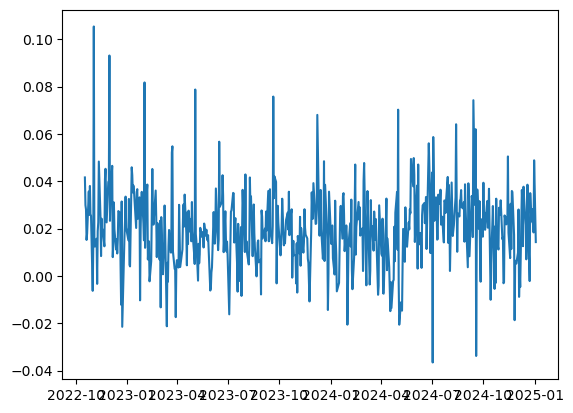

In [136]:
plt.plot(ab_params_df['autocorr_slope'])

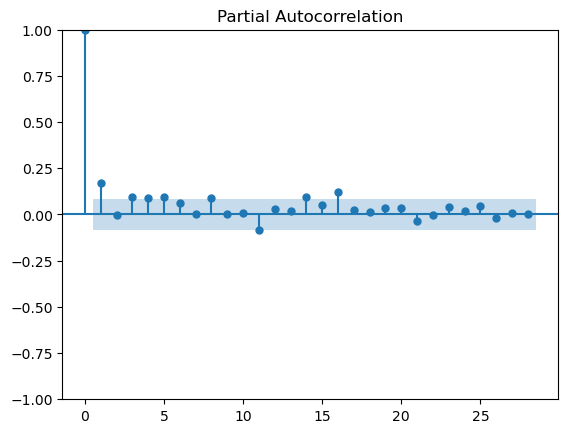

In [137]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_intercept']
)
plt.show()

In [138]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

SignificanceResult(statistic=np.float64(-0.01685657345345035), pvalue=np.float64(0.6916581773035666))

In [139]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.06473898117011023), pvalue=np.float64(0.12733720652028493))

In [140]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)
ab_params_df['shifted_autocorr_slope'] = ab_params_df['autocorr_slope'].shift(-1)
ab_params_df['shifted_autocorr_intercept'] = ab_params_df['autocorr_intercept'].shift(-1)

In [141]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_2'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_2']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1']))

lr_autocorr_slope = LinearRegression()

lr_autocorr_slope.fit(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope'])
print(lr_autocorr_slope.score(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope']))

lr_autocorr_intercept = LinearRegression()

lr_autocorr_intercept.fit(ab_params_df.dropna()[['a', 'b','shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept'])
print(lr_autocorr_intercept.score(ab_params_df.dropna()[['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept']))



0.6081823452755186
0.050930305018758504
0.06234886984997623
0.05087623038290512


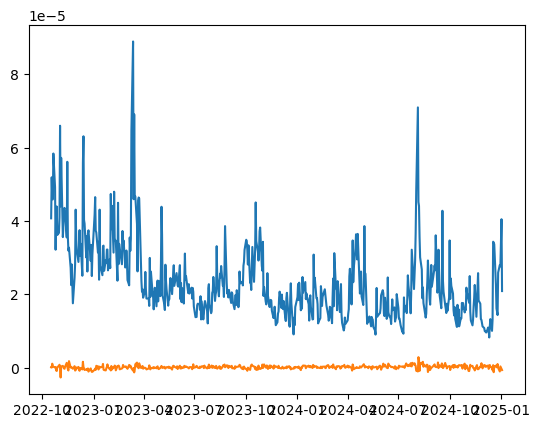

In [142]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

In [143]:
times

,Time
0,09:30:00
1,09:30:01
2,09:30:02
3,09:30:03
4,09:30:04
...,...
23396,15:59:56
23397,15:59:57
23398,15:59:58
23399,15:59:59


In [144]:
replicates = 10000
X0 = np.log ( (59026) / 59016)

T = np.arange(len(times)).reshape(len(times), 1).repeat(replicates, 1)

epsilon = np.random.laplace(
        loc=lr_a.predict(
            ab_params_df[
                ['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1], 
        scale=lr_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1],
        size=(len(ticker_hist_date), replicates)
    )

phi = lr_autocorr_slope.predict(
    ab_params_df[
        ['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

delta = lr_autocorr_intercept.predict(
    ab_params_df[
        ['a', 'b', 'shifted_b_1', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

In [145]:
possible_daily_returns = []

for r in tqdm(range(replicates)):
    possible = X0.copy()
    last_increment = X0.copy()
    for k in range(len(ticker_hist_date)):
        last_increment = phi * last_increment + delta + epsilon[k, r]
        possible += last_increment
    possible_daily_returns.append(possible)
        

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:51<00:00, 193.72it/s]


# declare spot ticker price

In [146]:
spot_spx_price = 5940

In [147]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_daily_returns))

In [148]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

5941.598029815577
29.345446651902364


In [117]:
upper_call = 5940.
lower_call = 5935.
upper_put = 5805.
lower_put = 5800.

In [118]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

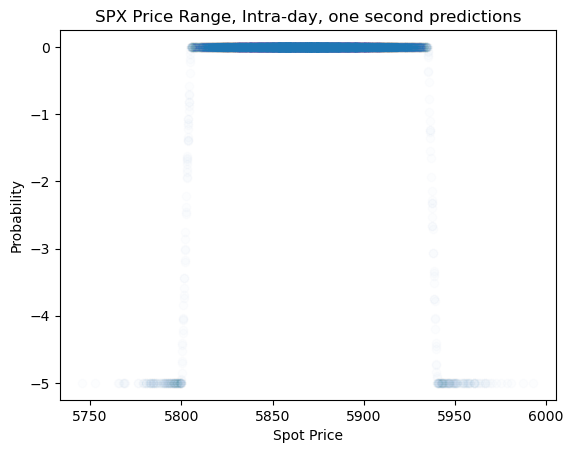

In [119]:
#plt.hist(possible_final_prices, bins = 100, density = True)
plt.ylabel('Probability')
plt.xlabel('Spot Price')
plt.title('SPX Price Range, Intra-day, one second predictions')
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
plt.scatter(possible_final_prices, payouts, alpha=0.01)
#mean_payout = np.round(np.mean(payouts), 2)
#plt.title(f'avg payout is {mean_payout}')
plt.show()

Text(0.5, 1.0, 'avg payout is -0.14')

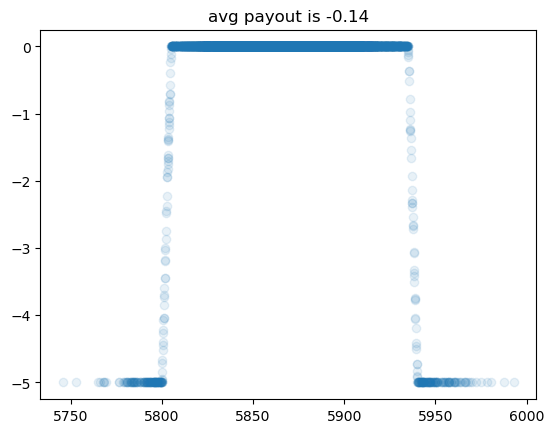

In [120]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

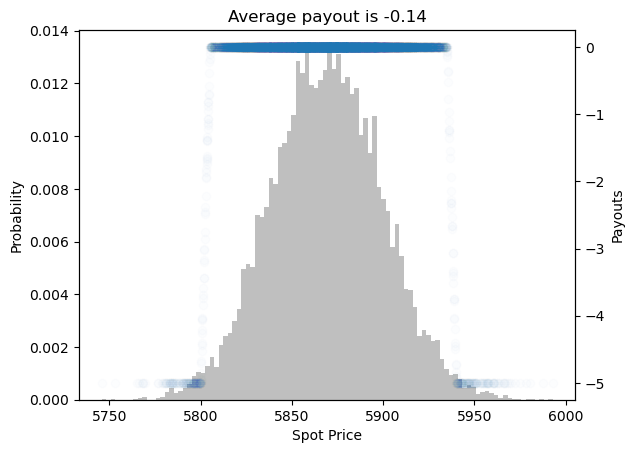

In [121]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
#plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [75]:
cost_of_trade = 0.70
max_loss = 5

In [76]:
p = (max_loss - cost_of_trade)/max_loss

In [77]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is -2.220446049250313e-16


In [78]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.36857142857142833
